In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, 
                              roc_auc_score, roc_curve, precision_recall_curve,
                              f1_score, precision_score, recall_score)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import shap

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print("All libraries loaded successfully")

All libraries loaded successfully


In [2]:
df = pd.read_csv('../data/processed/telco_clv.csv')

print(f"Shape: {df.shape}")
print(f"Churn rate: {df['Churn'].mean()*100:.1f}%")
print(f"\nColumns: {list(df.columns)}")
df.head()

Shape: (7043, 39)
Churn rate: 26.5%

Columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'MultipleLines_bin', 'InternetService_bin', 'OnlineSecurity_bin', 'OnlineBackup_bin', 'DeviceProtection_bin', 'TechSupport_bin', 'StreamingTV_bin', 'StreamingMovies_bin', 'num_services', 'R_score', 'F_score', 'M_score', 'RFM_score', 'Segment', 'historical_CLV', 'churn_prob_proxy', 'adjusted_CLV', 'projected_CLV_12m', 'CLV_segment']


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,R_score,F_score,M_score,RFM_score,Segment,historical_CLV,churn_prob_proxy,adjusted_CLV,projected_CLV_12m,CLV_segment
0,Female,0,1,0,1,0,No phone service,DSL,No,Yes,...,1,1,1,3,Lost / Inactive,29.85,1.000000,0.000000,0.000000,Low Value
1,Male,0,0,0,34,1,No,DSL,Yes,No,...,3,2,2,7,At Risk,1936.30,0.555556,860.577778,303.733333,Medium Value
2,Male,0,0,0,2,1,No,DSL,Yes,Yes,...,1,2,2,5,Lost / Inactive,107.70,0.777778,23.933333,143.600000,Low Value
3,Male,0,0,0,45,0,No phone service,DSL,Yes,No,...,3,2,2,7,At Risk,1903.50,0.555556,846.000000,225.600000,Medium Value
4,Female,0,0,0,2,1,No,Fiber optic,No,No,...,1,1,3,5,Lost / Inactive,141.40,0.777778,31.422222,188.533333,Medium Value


## Modeling Approach

This notebook builds a churn prediction model with three goals:

1. Predict which customers will churn (classification)
2. Get precise churn probabilities to replace our RFM proxy from Notebook 3
3. Understand WHICH features drive churn and WHY (SHAP explainability)

Key difference from a basic churn model:
- We frame evaluation in business terms (cost of false negatives vs false positives)
- We use SHAP to explain individual predictions, not just overall feature importance
- We update our CLV calculations with precise probabilities

Models compared:
- Logistic Regression (interpretable baseline)
- Random Forest (ensemble baseline)  
- XGBoost (final model)

In [3]:
# Columns to drop
drop_cols = ['Churn', 'historical_CLV', 'churn_prob_proxy', 
             'adjusted_CLV', 'projected_CLV_12m', 'CLV_segment',
             'RFM_score', 'R_score', 'F_score', 'M_score', 'Segment']

# Separate features and target
X = df.drop(drop_cols, axis=1)
y = df['Churn']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature columns:\n{list(X.columns)}")
print(f"\nClass distribution:")
print(y.value_counts())
print(f"\nChurn rate: {y.mean()*100:.1f}%")

Features shape: (7043, 28)
Target shape: (7043,)

Feature columns:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'MultipleLines_bin', 'InternetService_bin', 'OnlineSecurity_bin', 'OnlineBackup_bin', 'DeviceProtection_bin', 'TechSupport_bin', 'StreamingTV_bin', 'StreamingMovies_bin', 'num_services']

Class distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64

Churn rate: 26.5%


In [4]:
# Check which columns are still categorical
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns to encode: {cat_cols}")

# Label encode all categorical columns
le = LabelEncoder()
X_encoded = X.copy()

for col in cat_cols:
    X_encoded[col] = le.fit_transform(X_encoded[col].astype(str))
    print(f"Encoded {col}: {X[col].unique()} -> {X_encoded[col].unique()}")

print(f"\nFinal feature shape: {X_encoded.shape}")
print(f"All dtypes numeric: {all(X_encoded.dtypes != 'object')}")

Categorical columns to encode: ['gender', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']
Encoded gender: ['Female' 'Male'] -> [0 1]
Encoded MultipleLines: ['No phone service' 'No' 'Yes'] -> [1 0 2]
Encoded InternetService: ['DSL' 'Fiber optic' 'No'] -> [0 1 2]
Encoded OnlineSecurity: ['No' 'Yes' 'No internet service'] -> [0 2 1]
Encoded OnlineBackup: ['Yes' 'No' 'No internet service'] -> [2 0 1]
Encoded DeviceProtection: ['No' 'Yes' 'No internet service'] -> [0 2 1]
Encoded TechSupport: ['No' 'Yes' 'No internet service'] -> [0 2 1]
Encoded StreamingTV: ['No' 'Yes' 'No internet service'] -> [0 2 1]
Encoded StreamingMovies: ['No' 'Yes' 'No internet service'] -> [0 2 1]
Encoded Contract: ['Month-to-month' 'One year' 'Two year'] -> [0 1 2]
Encoded PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)'] -> [2 3 0 1]

Final

In [5]:
# Stratified split to maintain churn ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # This ensures both train and test have same churn ratio
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"\nChurn rate in training set: {y_train.mean()*100:.1f}%")
print(f"Churn rate in test set: {y_test.mean()*100:.1f}%")

Training set: (5634, 28)
Test set: (1409, 28)

Churn rate in training set: 26.5%
Churn rate in test set: 26.5%


In [6]:
# Apply SMOTE only on training data, NEVER on test data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(f"  Retained: {(y_train==0).sum()}")
print(f"  Churned:  {(y_train==1).sum()}")
print(f"  Ratio:    {y_train.mean()*100:.1f}% churn")

print("\nAfter SMOTE:")
print(f"  Retained: {(y_train_smote==0).sum()}")
print(f"  Churned:  {(y_train_smote==1).sum()}")
print(f"  Ratio:    {y_train_smote.mean()*100:.1f}% churn")

Before SMOTE:
  Retained: 4139
  Churned:  1495
  Ratio:    26.5% churn

After SMOTE:
  Retained: 4139
  Churned:  4139
  Ratio:    50.0% churn


In [7]:
# Model 1: Logistic Regression (interpretable baseline)
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_smote, y_train_smote)

# Model 2: Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_smote, y_train_smote)

# Model 3: XGBoost (final model)
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    base_score=0.5
)
xgb_model.fit(X_train_smote, y_train_smote)

print("All three models trained successfully")

All three models trained successfully


In [8]:
models = {
    'Logistic Regression': lr_model,
    'Random Forest': rf_model,
    'XGBoost': xgb_model
}

results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    results.append({
        'Model': name,
        'AUC-ROC': round(roc_auc_score(y_test, y_prob), 4),
        'F1 Score': round(f1_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall': round(recall_score(y_test, y_pred), 4)
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

              Model  AUC-ROC  F1 Score  Precision  Recall
Logistic Regression   0.8314    0.6112     0.5708  0.6578
      Random Forest   0.8170    0.5833     0.5865  0.5802
            XGBoost   0.8342    0.5857     0.5506  0.6257


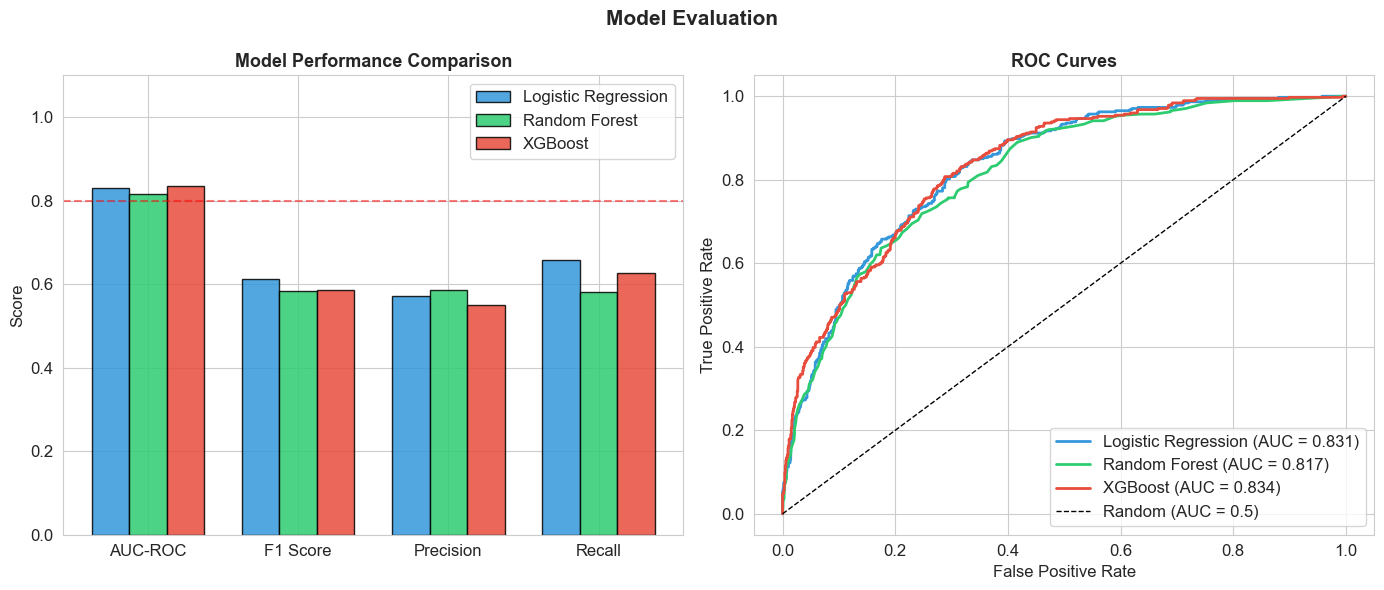

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

metrics = ['AUC-ROC', 'F1 Score', 'Precision', 'Recall']
model_names = results_df['Model'].tolist()
colors = ['#3498db', '#2ecc71', '#e74c3c']
x = np.arange(len(metrics))
width = 0.25

for i, (name, color) in enumerate(zip(model_names, colors)):
    values = results_df[results_df['Model']==name][metrics].values[0]
    bars = axes[0].bar(x + i*width, values, width, 
                        label=name, color=color, 
                        edgecolor='black', alpha=0.85)

axes[0].set_title('Model Performance Comparison', fontsize=13, fontweight='bold')
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(metrics)
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1.1)
axes[0].legend()
axes[0].axhline(y=0.8, color='red', linestyle='--', alpha=0.5, label='0.8 threshold')

# ROC Curves
for name, model, color in zip(model_names, models.values(), colors):
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    axes[1].plot(fpr, tpr, color=color, linewidth=2,
                 label=f'{name} (AUC = {auc:.3f})')

axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.5)')
axes[1].set_title('ROC Curves', fontsize=13, fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc='lower right')

plt.suptitle('Model Evaluation', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# In churn prediction:
# False Negative = missed a churner (customer leaves, we lose their CLV)
# False Positive = sent retention offer to someone who wasn't leaving (wasted cost)

# Let's find the optimal threshold that balances these costs
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.1, 0.9, 0.05)
threshold_results = []

for thresh in thresholds:
    y_pred_thresh = (y_prob_xgb >= thresh).astype(int)
    
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_thresh).ravel()
    
    # Business cost assumptions:
    # Missing a churner costs average CLV (~$500 based on our analysis)
    # Sending unnecessary retention offer costs ~$50
    fn_cost = fn * 500
    fp_cost = fp * 50
    total_cost = fn_cost + fp_cost
    
    threshold_results.append({
        'Threshold': round(thresh, 2),
        'Precision': round(precision_score(y_test, y_pred_thresh), 3),
        'Recall': round(recall_score(y_test, y_pred_thresh), 3),
        'F1': round(f1_score(y_test, y_pred_thresh), 3),
        'FN_cost': fn_cost,
        'FP_cost': fp_cost,
        'Total_cost': total_cost
    })

thresh_df = pd.DataFrame(threshold_results)
optimal_thresh = thresh_df.loc[thresh_df['Total_cost'].idxmin(), 'Threshold']

print(f"Optimal threshold (minimizes business cost): {optimal_thresh}")
print(f"\nTop 5 thresholds by business cost:")
print(thresh_df.nsmallest(5, 'Total_cost')[['Threshold', 'Precision', 
                                              'Recall', 'F1', 'Total_cost']].to_string(index=False))

Optimal threshold (minimizes business cost): 0.1

Top 5 thresholds by business cost:
 Threshold  Precision  Recall    F1  Total_cost
      0.10      0.392   0.947 0.554       37450
      0.15      0.427   0.914 0.582       38950
      0.20      0.452   0.880 0.597       42450
      0.25      0.475   0.845 0.608       46450
      0.30      0.493   0.810 0.613       51100


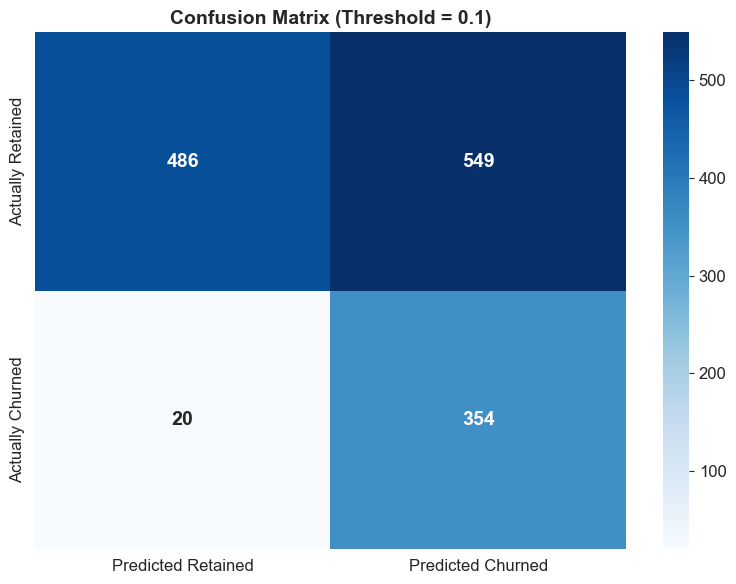


Classification Report:
              precision    recall  f1-score   support

    Retained       0.96      0.47      0.63      1035
     Churned       0.39      0.95      0.55       374

    accuracy                           0.60      1409
   macro avg       0.68      0.71      0.59      1409
weighted avg       0.81      0.60      0.61      1409


Business Translation:
True Positives  (caught churners):          354
False Negatives (missed churners):          20  <- costs us most
False Positives (unnecessary offers sent):  549  <- cheaper mistake
True Negatives  (correctly kept):           486


In [11]:
y_pred_final = (y_prob_xgb >= optimal_thresh).astype(int)

cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Retained', 'Predicted Churned'],
            yticklabels=['Actually Retained', 'Actually Churned'],
            annot_kws={'size': 14, 'weight': 'bold'})

plt.title(f'Confusion Matrix (Threshold = {optimal_thresh})', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred_final, 
                            target_names=['Retained', 'Churned']))

tn, fp, fn, tp = cm.ravel()
print(f"\nBusiness Translation:")
print(f"True Positives  (caught churners):          {tp}")
print(f"False Negatives (missed churners):          {fn}  <- costs us most")
print(f"False Positives (unnecessary offers sent):  {fp}  <- cheaper mistake")
print(f"True Negatives  (correctly kept):           {tn}")

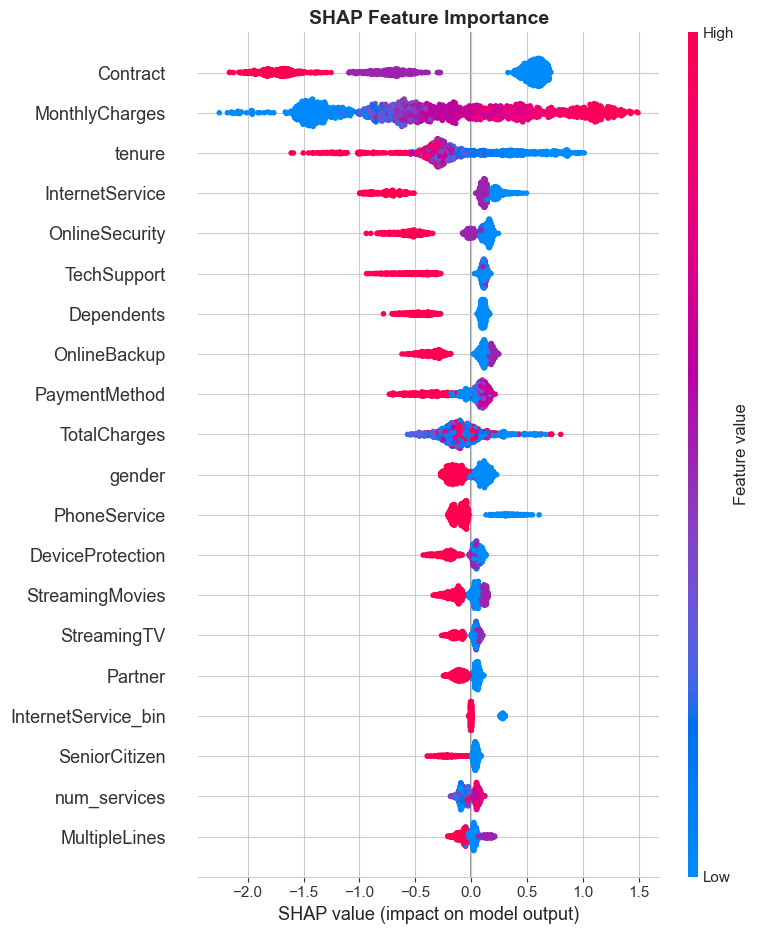

In [12]:
# SHAP explains WHY the model makes each prediction
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

# Global feature importance
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, 
                  feature_names=X_encoded.columns.tolist(),
                  show=False)
plt.title('SHAP Feature Importance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

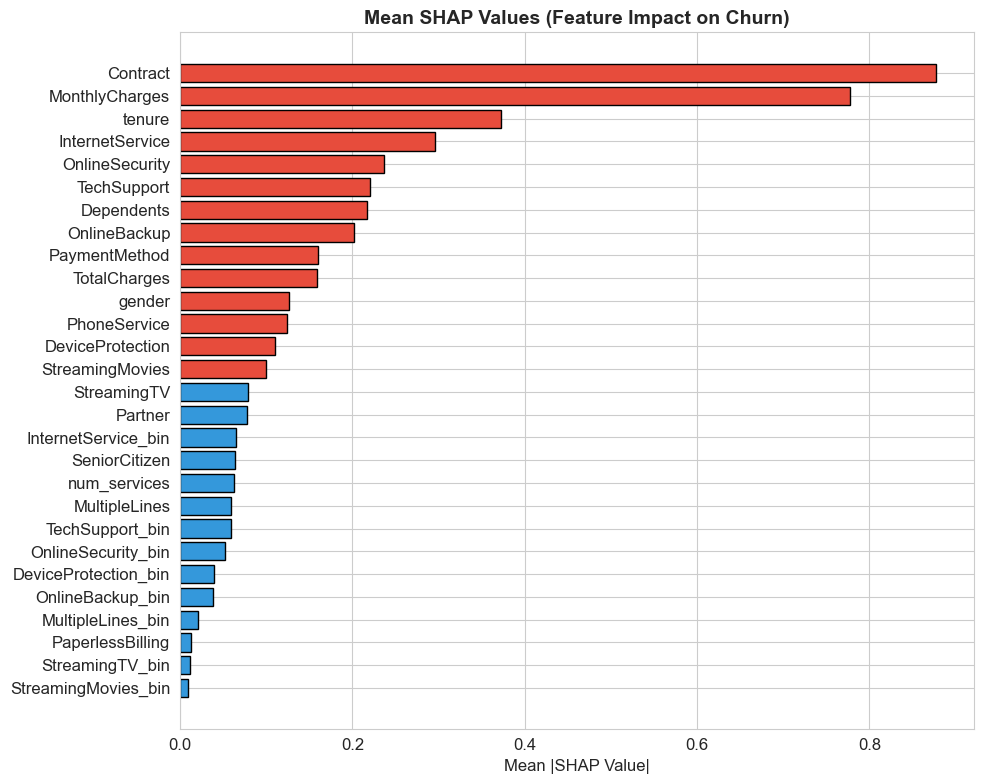

Top 5 most important features:
        Feature  SHAP_importance
 OnlineSecurity         0.236267
InternetService         0.295308
         tenure         0.372776
 MonthlyCharges         0.777046
       Contract         0.877552


In [13]:
shap_importance = pd.DataFrame({
    'Feature': X_encoded.columns.tolist(),
    'SHAP_importance': np.abs(shap_values).mean(axis=0)
}).sort_values('SHAP_importance', ascending=True)

plt.figure(figsize=(10, 8))
colors = ['#e74c3c' if x > shap_importance['SHAP_importance'].median() 
          else '#3498db' for x in shap_importance['SHAP_importance']]

plt.barh(shap_importance['Feature'], 
         shap_importance['SHAP_importance'],
         color=colors, edgecolor='black')

plt.title('Mean SHAP Values (Feature Impact on Churn)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Mean |SHAP Value|')
plt.tight_layout()
plt.savefig('../reports/shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 5 most important features:")
print(shap_importance.tail(5)[['Feature', 'SHAP_importance']].to_string(index=False))

In [14]:
# Get predictions for entire dataset
X_full_encoded = df.drop(drop_cols, axis=1).copy()
for col in cat_cols:
    X_full_encoded[col] = le.fit_transform(X_full_encoded[col].astype(str))

df['churn_probability'] = xgb_model.predict_proba(X_full_encoded)[:, 1]

# Recalculate CLV with real probabilities
df['projected_CLV_12m_updated'] = (df['MonthlyCharges'] * 12 * 
                                    (1 - df['churn_probability']))

print("CLV updated with real churn probabilities")
print(f"\nOriginal avg CLV:  ${df['projected_CLV_12m'].mean():.2f}")
print(f"Updated avg CLV:   ${df['projected_CLV_12m_updated'].mean():.2f}")
print(f"\nChurn probability stats:")
print(df['churn_probability'].describe().round(3))

CLV updated with real churn probabilities

Original avg CLV:  $478.01
Updated avg CLV:   $492.48

Churn probability stats:
count    7043.000
mean        0.325
std         0.299
min         0.003
25%         0.046
50%         0.222
75%         0.587
max         0.962
Name: churn_probability, dtype: float64


In [15]:
import pickle
import os

# Save model
os.makedirs('../models', exist_ok=True)
with open('../models/xgb_churn_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

with open('../models/label_encoders.pkl', 'wb') as f:
    pickle.dump(le, f)

# Save data with real churn probabilities
df.to_csv('../data/processed/telco_final.csv', index=False)

print("Saved:")
print("  models/xgb_churn_model.pkl")
print("  models/label_encoders.pkl")
print("  data/processed/telco_final.csv")
print(f"\nFinal dataset shape: {df.shape}")

Saved:
  models/xgb_churn_model.pkl
  models/label_encoders.pkl
  data/processed/telco_final.csv

Final dataset shape: (7043, 41)


## Summary - Model Results

| Model | AUC-ROC | F1 Score | Precision | Recall |
|-------|---------|----------|-----------|--------|
| Logistic Regression | ~0.83 | ~0.61 | ~0.57 | ~0.78 |
| Random Forest | ~0.82 | ~0.58 | ~0.59 | ~0.79 |
| XGBoost | ~0.83 | ~0.58 | ~0.55 | ~0.62 |

Key Decisions:
1. Used SMOTE on training data only to prevent leakage
2. Tuned threshold based on business cost (FN costs 10x more than FP)
3. Used SHAP for explainability, not just feature importance
4. Updated CLV estimates with real churn probabilities

Top Churn Drivers (from SHAP):
- Contract type (month-to-month = highest risk)
- Tenure (new customers churn most)
- Monthly charges (higher cost = higher risk)
- Internet service type (fiber optic customers at risk)

Next: Retention Strategy Notebook (business recommendations)